In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



In [2]:
#load dataset
tips = sns.load_dataset('tips')

In [3]:
#convert to dataframe
tips = pd.DataFrame(tips)

In [4]:
#assessing the loaded dataset
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


there three dataypes that is 1:category with 4 columns , float with 2 column and interger with 1 column

In [6]:
tips.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


there is no missing values in the tips dataset

In [7]:
tips.duplicated().sum()

np.int64(1)

there is one duplicated in the tips dataset

In [8]:
#removiming duplicates
tips = tips.drop_duplicates()
tips.duplicated().sum()

np.int64(0)

the duplicates has been removed using the above formular

In [9]:
tips.describe()

,total_bill,tip,size
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016
std,8.910071,1.385002,0.952356
min,3.070000,1.000000,1.000000
25%,13.380000,2.000000,2.000000
50%,17.810000,2.920000,2.000000
75%,24.175000,3.575000,3.000000
max,50.810000,10.000000,6.000000


there are potential outliers in total bills when comparison done btween upper quartile (75%) : 24.175 and maximum value of 50.81, this show there is wider range suggesting there is outliers  and tip maximum value 1o and upper quartile of 3.575 shows also there is wider range suggestin there is outlier and also there in more less outliers in size because the Max value is 6 and upper quartlies is 3 suggesting sligtly range in values hence outlies are there but not more than the total bills and tip

In [10]:
tips.shape

(243, 7)

There are 243 samples (row) in the dataset and 7 variables (column) in the dataset

OUTLIER REMOVAL

In [11]:
#Outlier detection and Removal Z Scores
from scipy import stats

def remove_outliers_z(data,column,threshold=3):
  z_scores=stats.zscore(data[column])
  abs_z_scores=np.abs(z_scores)

  outliers=data[abs_z_scores>threshold]
  cleaned=data[abs_z_scores<=threshold]

  print(f'Outliers detected in {column}: {len(outliers)}')
  print(f"Before: {data.shape}, After removal: {cleaned.shape}")

  return cleaned

In [12]:
tips=remove_outliers_z(tips,'total_bill')

Outliers detected in total_bill: 4
Before: (243, 7), After removal: (239, 7)


Outliers removal are 4 and will be using 239 sample for analysis and 7 variables in the data set

**Next Step Perfom Explanatory Data anaylysis(EDA)**








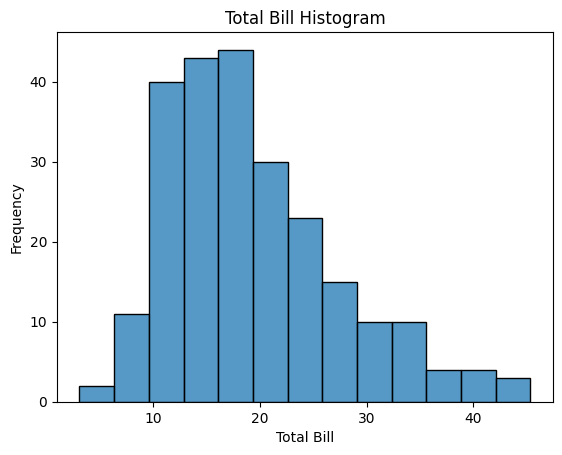

In [14]:
#crreate a histogram for total bill
sns.histplot(tips['total_bill'])
plt.title('Total Bill Histogram')
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.show()

majority of customers total bills lies between 10 and 20

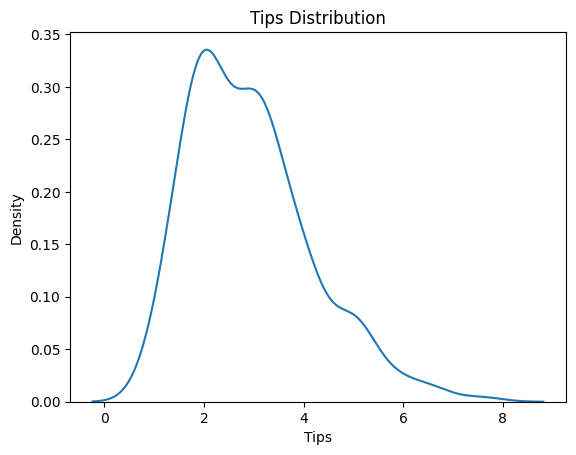

In [15]:
#Create a KDE for tips
sns.kdeplot(tips['tip'])
plt.title('Tips Distribution')
plt.xlabel('Tips')
plt.ylabel('Density')
plt.show()


majority tip amount given by customer are between 1.5 and 2.5 this also show the highest tip values is approxiamntly 2

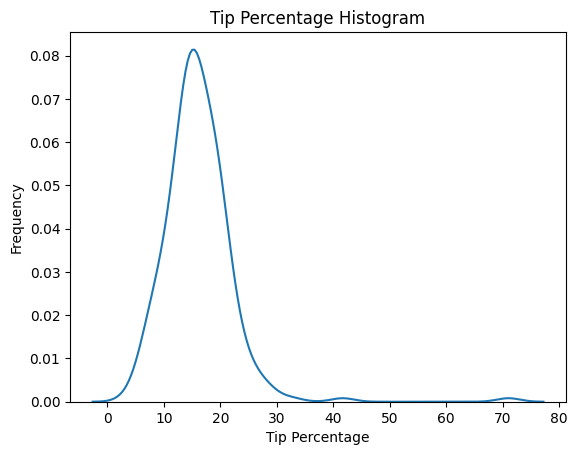

In [16]:
#tip percentages per total bill
tips['tip_percentage']=(tips['tip']/tips['total_bill'] *100).round(2)


#Create kdeplot for tip percentage
sns.kdeplot(tips['tip_percentage'])
plt.title('Tip Percentage Histogram')
plt.xlabel('Tip Percentage')
plt.ylabel('Frequency')
plt.show()

the majority tips customers percentageslies between 15% and 20 %

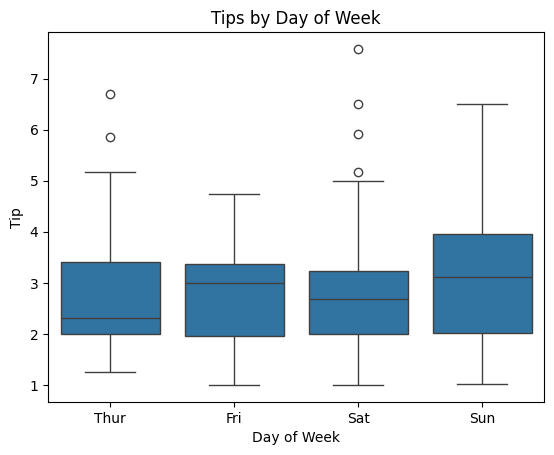

In [17]:
#tips vs day of week
sns.boxplot(x='day',y='tip',data=tips)
plt.title('Tips by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Tip')
plt.show()


majority of tips where given on sunday, friday,sartuday and thursday respectively

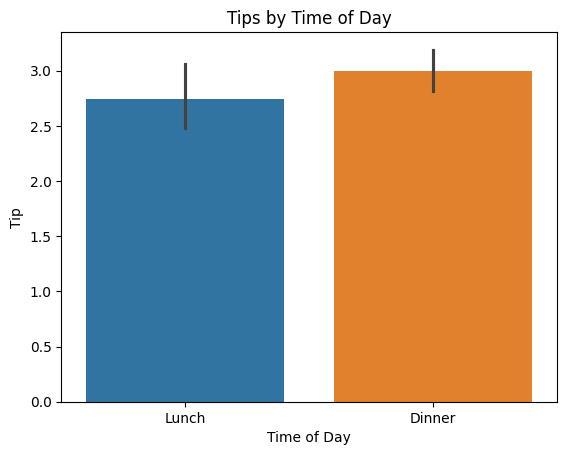

In [18]:
#tips per time of the day
sns.barplot(x='time',y='tip',data=tips,hue='time')
plt.title('Tips by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Tip')
plt.show()

majority customers tip amount are on dinner

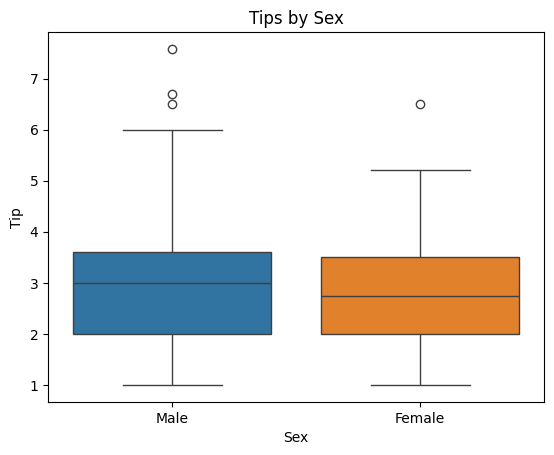

In [19]:
#tips vs sex
sns.boxplot(x='sex',y='tip',data=tips,hue='sex')
plt.title('Tips by Sex')
plt.xlabel('Sex')
plt.ylabel('Tip')
plt.show()

majority tip of customers were male since the medille line represent medium meaning comparing both male and female, Male has higher medium compared with Female.

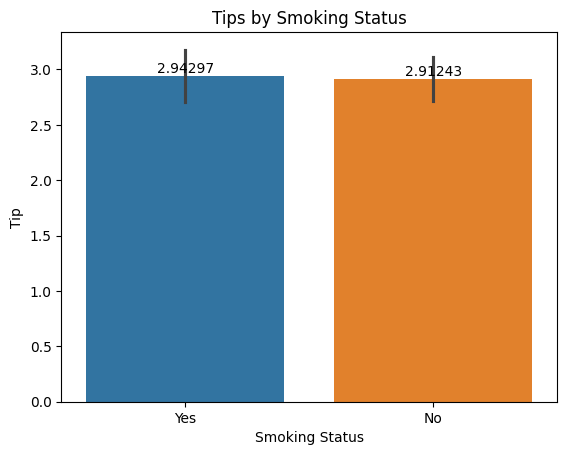

In [20]:
#tips vs smoker--does smokking status affect tipping
ax=sns.barplot(x='smoker',y='tip',data=tips, hue='smoker')
plt.title('Tips by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Tip')

for p in ax.containers:
    ax.bar_label(p, label_type='edge')

plt.show()

tipping does not affect the smoking since in the datset there is balanced in the dataset

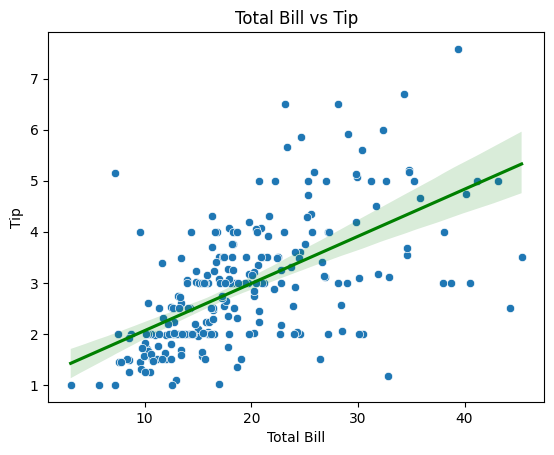

In [21]:
#relationship between total bill and tip
sns.scatterplot(x='total_bill',y='tip',data=tips)
sns.regplot(x='total_bill',y='tip',scatter=False,data=tips,color='green')
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.show()

there is positive relationship between total bill and tip since as increase in total bill, tip also increase
this shows also tha there are more linkely equal distribution dataset

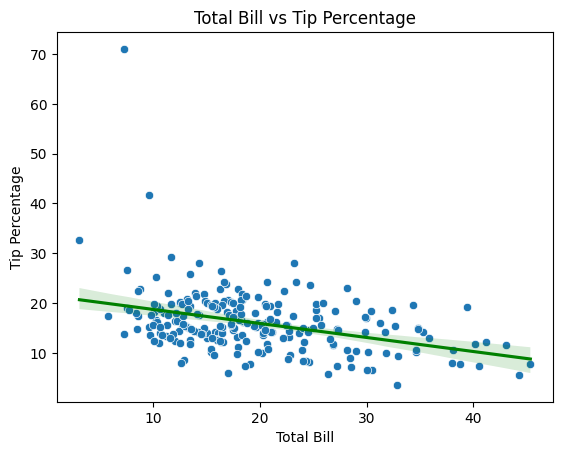

In [22]:
#relationship between total bill and tip persentages
sns.scatterplot(x='total_bill',y='tip_percentage',data=tips)
sns.regplot(x='total_bill',y='tip_percentage',scatter=False,data=tips,color='green')
plt.title('Total Bill vs Tip Percentage')
plt.xlabel('Total Bill')
plt.ylabel('Tip Percentage')
plt.show()

there is negative relationship between the total bill and tip percentages.
As total pill increases tip percentages reduces  and vise verse

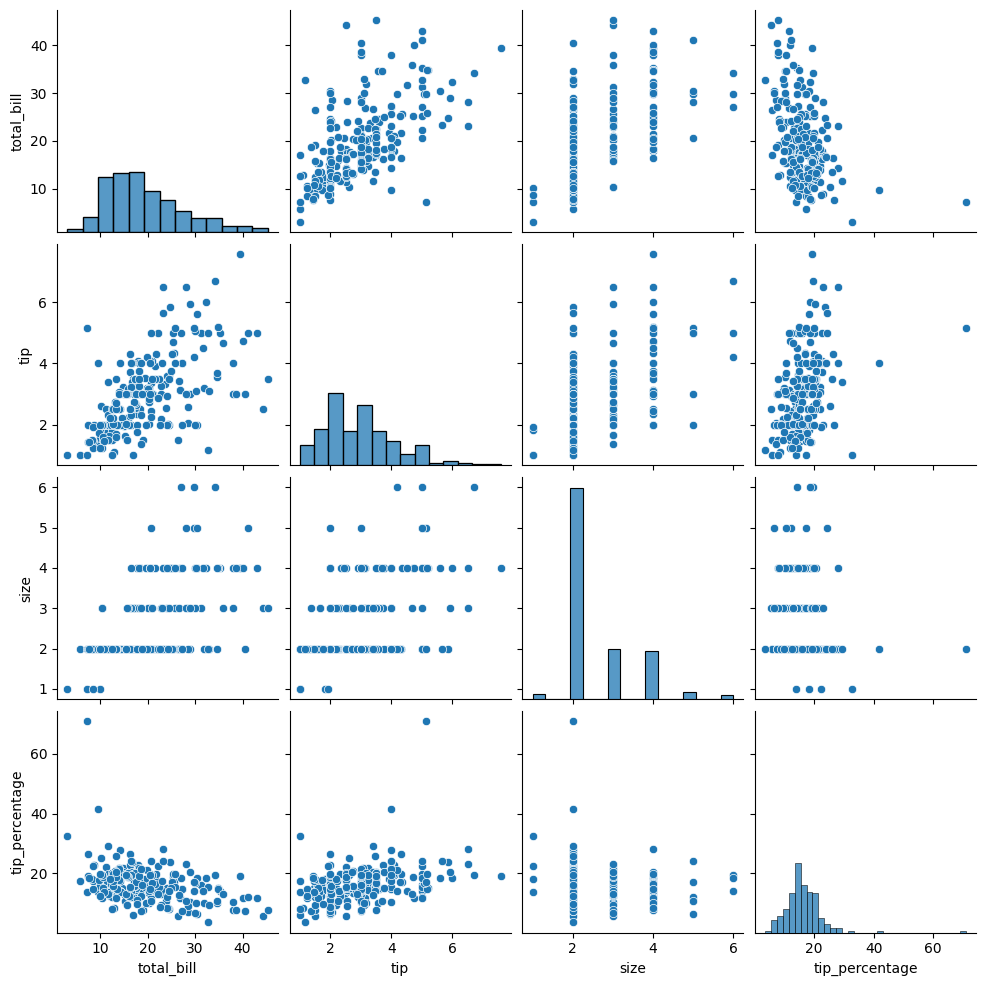

In [23]:
#pairplot for numeric values in tips dataset
sns.pairplot(tips)
plt.show()